# 50 – Zoning-Constrained KPI Analysis (TOCs and Villages)

This notebook addresses the following KPI feedback:

> Highlight the extent to which current zoning entitlements may be stifling the potential of TOC and Village Cores due to strict use, density, and height constraints.

**Approach:**
1. Load the generalized zoning layer and filter to qualifying zones (C-1, C-2, C-3, R-3).
2. Exclude parcels in historic preservation districts (HP or HP-L).
3. Subtract the Infill Development District (IDD) — those areas are exempt from the 30 ft / 17.40 du/ac constraints.
4. Intersect the remaining "constrained zones" with TOC and Village boundaries.
5. For each geography, compute the same KPIs used in prior notebooks:
   - **Area metrics**: constrained acres, share of total boundary area
   - **Fiscal efficiency**: taxable value per acre, full cash value per acre
   - **Employment**: jobs per acre (LODES 2022)
   - **Demographics**: population/HH density, median income, median rent, commute mode shares (ACS 2019–2023)
   - **Parcel count** within constrained zones

**Key constraint rule being flagged:**
- C-1 through C-3 and R-3 zones (outside IDD) are limited to **30 feet** in height and **17.40 dwelling units per gross acre**.

## 0. Setup

In [1]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR     = PROJECT_ROOT / "data"
OUTPUTS_DIR  = PROJECT_ROOT / "outputs"

ZONING_DIR     = DATA_DIR / "zoning"
BOUNDARIES_DIR = DATA_DIR / "boundaries" / "processed"
PARCELS_DIR    = DATA_DIR / "parcels" / "processed"
JOBS_DIR       = DATA_DIR / "jobs" / "lodes_processed"
CENSUS_DIR     = DATA_DIR / "census" / "processed"

PROJECT_CRS = "EPSG:2868"
SQ_FT_PER_ACRE = 43560.0

# ── Qualifying zone codes (exact match) ──────────────────────────────────────
QUALIFYING_ZONES = ["C-1", "C-2", "C-3", "R-3"]

# ── Height / density constraint being flagged ─────────────────────────────────
MAX_HEIGHT_FT  = 30
MAX_DU_PER_ACRE = 17.40

print("Directories confirmed:")
for d in [ZONING_DIR, BOUNDARIES_DIR, PARCELS_DIR, JOBS_DIR, CENSUS_DIR]:
    print(f"  {'OK' if d.exists() else 'MISSING'}: {d}")

Directories confirmed:
  OK: d:\ASU Archive\Archive - GIS 222\toc-performance-dashboard\data\zoning
  OK: d:\ASU Archive\Archive - GIS 222\toc-performance-dashboard\data\boundaries\processed
  OK: d:\ASU Archive\Archive - GIS 222\toc-performance-dashboard\data\parcels\processed
  OK: d:\ASU Archive\Archive - GIS 222\toc-performance-dashboard\data\jobs\lodes_processed
  OK: d:\ASU Archive\Archive - GIS 222\toc-performance-dashboard\data\census\processed


## 1. Load and Filter the Zoning Layer

In [2]:
# ── File path ─────────────────────────────────────────────────────────────────
# UPDATE this filename to match the actual shapefile name you received.
raw_zoning_path = ZONING_DIR / "Zoning.shp"   # <-- update me

zoning_raw = gpd.read_file(raw_zoning_path)

print("Features:", len(zoning_raw))
print("CRS:", zoning_raw.crs)
print("Columns:", zoning_raw.columns.tolist())
zoning_raw.head()

Features: 9480
CRS: EPSG:2868
Columns: ['OBJECTID', 'ACRES', 'ZPREFIX', 'ZCASE', 'ZREVISION', 'ZYEAR', 'SPPREFIX', 'SPCASE', 'SPREVISION', 'SPYEAR', 'ZONING', 'REDEFINE1', 'DATE_APPRO', 'LABEL1', 'ORD_NUM', 'HISTORIC', 'GEN_ZONE', 'INSERT_DAT', 'UPDATE_DAT', 'ANID', 'TOD', 'geometry']


,OBJECTID,ACRES,ZPREFIX,ZCASE,ZREVISION,ZYEAR,SPPREFIX,SPCASE,SPREVISION,SPYEAR,...,DATE_APPRO,LABEL1,ORD_NUM,HISTORIC,GEN_ZONE,INSERT_DAT,UPDATE_DAT,ANID,TOD,geometry
0,2954982,4.513859,Z,None,None,None,None,None,None,None,...,None,C-2,None,None,Commercial,2023-04-17,2024-09-09,71271,None,"POLYGON ((659282.310 912584.500, 659281.183 91..."
1,2954983,1.933360,Z,None,None,None,None,None,None,None,...,None,C-2,None,None,Commercial,2023-04-17,2024-09-09,71272,None,"POLYGON ((653440.630 935459.060, 653437.250 93..."
2,2954984,74.341618,Z,None,None,None,None,None,None,None,...,None,R1-6 HP,None,HP,SF Residential,2023-04-17,2024-09-09,71273,None,"POLYGON ((652822.760 914700.870, 652822.630 91..."
3,2954985,1.099903,Z,None,None,None,SP,9,None,91,...,None,C-2 SP SPD*,G-3827,None,Commercial,2023-04-17,2025-03-06,71274,None,"POLYGON ((654913.440 900961.370, 654917.560 90..."
4,2954986,2.081568,Z,None,None,None,None,None,None,None,...,None,C-2,None,None,Commercial,2023-04-17,2024-09-09,71275,None,"POLYGON ((638926.160 892231.000, 638922.190 89..."


In [3]:
# Inspect unique values in ZONING and HISTORIC fields before filtering
print("Unique ZONING values (sample):")
print(zoning_raw["ZONING"].value_counts().head(20))

print("\nUnique HISTORIC values:")
print(zoning_raw["HISTORIC"].value_counts(dropna=False))

Unique ZONING values (sample):
ZONING
C-2       1610
R1-6       689
R-3        686
R-5        642
C-1        494
R-4        414
P-1        408
C-O        364
S-1        348
R1-10      344
R-2        335
R1-8       300
A-1        271
C-3        246
R-3A       245
PUD        209
CP/GCP     152
RE-35      139
R1-18      127
A-2        116
Name: count, dtype: int64

Unique HISTORIC values:
HISTORIC
None    9015
HP       448
HP-L      15
HP L       2
Name: count, dtype: int64


In [4]:
# Reproject to project CRS if necessary
if zoning_raw.crs != PROJECT_CRS:
    print(f"Reprojecting zoning from {zoning_raw.crs} to {PROJECT_CRS}")
    zoning_raw = zoning_raw.to_crs(PROJECT_CRS)
else:
    print("Zoning CRS already matches PROJECT_CRS — no reprojection needed.")

Zoning CRS already matches PROJECT_CRS — no reprojection needed.


In [5]:
# Step 1a: Keep only qualifying zone types
zoning_qualifying = zoning_raw[zoning_raw["ZONING"].isin(QUALIFYING_ZONES)].copy()
print(f"Qualifying zone features ({', '.join(QUALIFYING_ZONES)}): {len(zoning_qualifying)}")

# Step 1b: Drop historic preservation districts (HP or HP-L)
# Blank / NaN values = not historic, so we exclude rows where HISTORIC is non-empty
historic_mask = zoning_qualifying["HISTORIC"].isin(["HP", "HP-L"])
print(f"  Removing {historic_mask.sum()} features in historic districts.")
zoning_qualifying = zoning_qualifying[~historic_mask].copy()
print(f"  Remaining qualifying (non-historic) features: {len(zoning_qualifying)}")

# Quick geometry check
zoning_qualifying.loc[~zoning_qualifying.is_valid, "geometry"] = (
    zoning_qualifying.loc[~zoning_qualifying.is_valid, "geometry"].buffer(0)
)

zoning_qualifying[["ZONING", "HISTORIC", "geometry"]].head()

Qualifying zone features (C-1, C-2, C-3, R-3): 3036
  Removing 113 features in historic districts.
  Remaining qualifying (non-historic) features: 2923


,ZONING,HISTORIC,geometry
0,C-2,None,"POLYGON ((659282.310 912584.500, 659281.183 91..."
1,C-2,None,"POLYGON ((653440.630 935459.060, 653437.250 93..."
3,C-2,None,"POLYGON ((654913.440 900961.370, 654917.560 90..."
4,C-2,None,"POLYGON ((638926.160 892231.000, 638922.190 89..."
12,C-1,None,"POLYGON ((633949.600 938672.350, 633947.860 93..."


## 2. Load and Filter the Infill Development District (IDD)

Areas inside the IDD are **not** subject to the 30 ft / 17.40 du/ac constraint and should be excluded from the constrained zone.

In [6]:
# ── File path ─────────────────────────────────────────────────────────────────
# UPDATE this filename to match the actual IDD shapefile.
idd_path = ZONING_DIR / "Infill_Development" / "Infill_Development.shp"  # <-- update me

idd_raw = gpd.read_file(idd_path)

print("IDD features:", len(idd_raw))
print("CRS:", idd_raw.crs)
print("Columns:", idd_raw.columns.tolist())
idd_raw

IDD features: 2
CRS: EPSG:2868
Columns: ['OBJECTID', 'PIN', 'ANID', 'geometry']


,OBJECTID,PIN,ANID,geometry
0,1,SFA,10,"MULTIPOLYGON (((642882.356 915631.286, 642868...."
1,641,INFILL,11,"POLYGON ((642916.590 918970.918, 642946.438 91..."


IDD records after filter: 1
IDD CRS already matches PROJECT_CRS.


<Axes: >

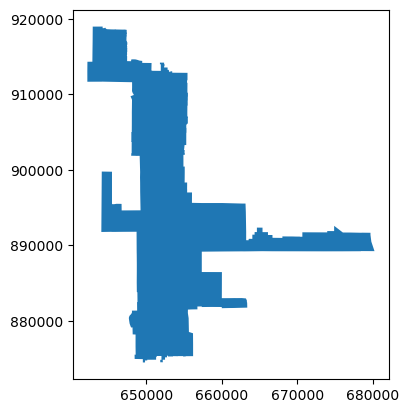

In [7]:
# ── PLACEHOLDER — update the filter below once you inspect the field values ──
#
# The shapefile has two records:
#   1. The main Infill Development District
#   2. An "applicable single-family infill option"
#
# Update the field name and value to select only the main district.
# Example (replace with actual field/value):
#   idd = idd_raw[idd_raw["DISTRICT_TYPE"] == "Infill Development District"].copy()
#
IDD_FIELD = "PIN"   # <-- update me
IDD_VALUE = "INFILL"        # <-- update me

idd = idd_raw[idd_raw[IDD_FIELD] == IDD_VALUE].copy()
print(f"IDD records after filter: {len(idd)}")

if idd.crs != PROJECT_CRS:
    idd = idd.to_crs(PROJECT_CRS)
    print(f"Reprojected IDD to {PROJECT_CRS}")
else:
    print("IDD CRS already matches PROJECT_CRS.")

idd[["geometry"]].plot()

## 3. Build the Constrained Zone Layer

Remove IDD areas from the qualifying zones via a spatial difference.

In [8]:
# Dissolve IDD to a single geometry for a clean difference operation
idd_dissolved = idd.dissolve().reset_index(drop=True)

# Difference: qualifying zones minus IDD
constrained_zones = gpd.overlay(
    zoning_qualifying,
    idd_dissolved[["geometry"]],
    how="difference",
    keep_geom_type=True
)

# Drop empty/null geometries that can result from the difference
constrained_zones = constrained_zones[
    constrained_zones.geometry.notna() & ~constrained_zones.geometry.is_empty
].copy()

# Add area column (sq ft and acres)
constrained_zones["zone_sqft"]  = constrained_zones.geometry.area
constrained_zones["zone_acres"] = constrained_zones["zone_sqft"] / SQ_FT_PER_ACRE

print(f"Constrained zone features: {len(constrained_zones)}")
print(f"Total constrained acres: {constrained_zones['zone_acres'].sum():,.0f}")
constrained_zones[["ZONING", "zone_acres"]].groupby("ZONING").agg(
    feature_count=("zone_acres", "count"),
    total_acres=("zone_acres", "sum")
).round(1)

Constrained zone features: 2585
Total constrained acres: 25,262


,feature_count,total_acres
ZONING,,
C-1,428,1598.1
C-2,1414,12088.5
C-3,165,1924.5
R-3,578,9650.7


## 4. Load Boundary and Analysis Layers

Load the cleaned TOC and Village boundaries, parcels (with assessor), LODES jobs, and ACS tracts.

In [9]:
toc     = gpd.read_file(BOUNDARIES_DIR / "toc_clean.gpkg").to_crs(PROJECT_CRS)
village = gpd.read_file(BOUNDARIES_DIR / "village_clean.gpkg").to_crs(PROJECT_CRS)

print("TOC features:", len(toc))
print("Village features:", len(village))

TOC features: 11
Village features: 15


In [10]:
parcels = gpd.read_file(
    PARCELS_DIR / "maricopa_parcels_with_assessor.gpkg"
).to_crs(PROJECT_CRS)

# Compute area and drop zero-area rows
parcels["area_acres"] = parcels.geometry.area / SQ_FT_PER_ACRE
parcels = parcels[parcels["area_acres"] > 0].copy()

print("Parcels loaded:", len(parcels))

Parcels loaded: 1736192


In [11]:
lodes = gpd.read_file(
    JOBS_DIR / "lodes_jobs_2022_with_geometry.gpkg"
).to_crs(PROJECT_CRS)

if "jobs_total" not in lodes.columns:
    lodes["jobs_total"] = lodes["C000"].fillna(0)
if "area_sq_ft" not in lodes.columns:
    lodes["area_sq_ft"] = lodes.geometry.area

print("LODES block groups loaded:", len(lodes))

LODES block groups loaded: 2806


In [12]:
tracts_acs = gpd.read_file(
    CENSUS_DIR / "tracts_acs_2019_2023.gpkg"
).to_crs(PROJECT_CRS)

# ── ACS field constants (mirroring notebooks 16 / 21) ────────────────────────
TOTAL_POPULATION      = "ASNQE001"
MEDIAN_HH_INCOME      = "ASQPE001"
MEDIAN_RENT           = "ASVBE001"
HOUSING_TOTAL         = "ASS8E001"
OCCUPIED_HH           = "ASS8E002"
VACANT_UNITS          = "ASS8E003"
OWNER_OCCUPIED        = "ASS9E002"
RENTER_OCCUPIED       = "ASS9E003"
TOTAL_WORKERS_16P     = "ASORE001"
DRIVE_ALONE           = "ASORE003"
CARPOOLED             = "ASORE004"
PUBLIC_TRANSPORT      = "ASORE010"
BICYCLE               = "ASORE018"
WALKED                = "ASORE019"
WORKED_FROM_HOME      = "ASORE021"
AUTO_COMMUTERS        = "ASORE002"

ACS_COUNT_COLS = [
    TOTAL_POPULATION, HOUSING_TOTAL, OCCUPIED_HH, VACANT_UNITS,
    OWNER_OCCUPIED, RENTER_OCCUPIED, TOTAL_WORKERS_16P,
    DRIVE_ALONE, CARPOOLED, PUBLIC_TRANSPORT,
    BICYCLE, WALKED, WORKED_FROM_HOME, AUTO_COMMUTERS,
]

for col in ACS_COUNT_COLS + [MEDIAN_HH_INCOME, MEDIAN_RENT]:
    tracts_acs[col] = pd.to_numeric(tracts_acs[col], errors="coerce")

# Mask invalid sentinel values for medians
for col in [MEDIAN_HH_INCOME, MEDIAN_RENT]:
    tracts_acs.loc[(tracts_acs[col] <= 0) | (tracts_acs[col] > 1_000_000), col] = np.nan

tracts_acs["tract_sqft"] = tracts_acs.geometry.area

print("ACS tracts loaded:", len(tracts_acs))

ACS tracts loaded: 1009


## 5. Helper Functions

Reusable functions for area metrics, parcel metrics, LODES jobs, and ACS demographics — mirroring the approach in notebooks 15–22.

In [13]:
def compute_area_metrics(constrained_zones, boundary_gdf, boundary_id_col, boundary_name_col):
    """
    Intersect constrained zones with a boundary layer and return per-boundary
    summary of constrained acreage and share of total boundary area.
    """
    # Prepare boundary areas
    bounds = boundary_gdf[[boundary_id_col, boundary_name_col, "geometry"]].copy()
    bounds["boundary_sqft"] = bounds.geometry.area
    bounds["boundary_acres"] = bounds["boundary_sqft"] / SQ_FT_PER_ACRE

    # Dissolve constrained zones to avoid double-counting overlapping zone polygons
    zones_dissolved = constrained_zones.dissolve().reset_index(drop=True)[["geometry"]]

    # Intersect
    intersected = gpd.overlay(
        zones_dissolved,
        bounds,
        how="intersection",
        keep_geom_type=False
    )
    intersected = intersected[
        intersected.geometry.notna() & ~intersected.geometry.is_empty
    ].copy()
    intersected["intersect_sqft"]  = intersected.geometry.area
    intersected["intersect_acres"] = intersected["intersect_sqft"] / SQ_FT_PER_ACRE

    # Aggregate to boundary level
    agg = (
        intersected
        .groupby([boundary_id_col, boundary_name_col], as_index=False)
        .agg(constrained_acres=("intersect_acres", "sum"))
    )

    result = bounds.drop(columns="geometry").merge(agg, on=[boundary_id_col, boundary_name_col], how="left")
    result["constrained_acres"] = result["constrained_acres"].fillna(0)
    result["pct_boundary_constrained"] = (
        result["constrained_acres"] / result["boundary_acres"] * 100
    ).round(2)

    return result, intersected

In [14]:
def compute_parcel_metrics(parcels, constrained_in_boundary, boundary_id_col):
    """
    Spatial-join parcels to constrained-zone slices within a boundary and
    return taxable value per acre, FCV per acre, land value per acre, and parcel count.
    """
    # Use parcel centroids for the join to avoid double-counting split parcels
    parcel_centroids = parcels.copy()
    parcel_centroids["geometry"] = parcel_centroids.geometry.centroid

    # Dissolve constrained zones within each boundary to a single polygon per boundary
    constrained_dissolved = (
        constrained_in_boundary
        .dissolve(by=boundary_id_col, as_index=False)[[boundary_id_col, "geometry"]]
    )

    joined = gpd.sjoin(
        parcel_centroids[["APN", "area_acres", "LPVASSESSEDVALUE",
                           "FULLCASHVALUE", "LANDFULLCASHVALUE", "geometry"]],
        constrained_dissolved,
        how="inner",
        predicate="within"
    )

    result = (
        joined
        .groupby(boundary_id_col, as_index=False)
        .agg(
            parcel_count=("APN", "count"),
            total_taxable_value=("LPVASSESSEDVALUE", "sum"),
            total_fcv=("FULLCASHVALUE", "sum"),
            total_land_value=("LANDFULLCASHVALUE", "sum"),
            parcel_acres=("area_acres", "sum"),
        )
    )

    result["taxable_value_per_acre"] = result["total_taxable_value"] / result["parcel_acres"]
    result["fcv_per_acre"]           = result["total_fcv"] / result["parcel_acres"]
    result["land_value_per_acre"]    = result["total_land_value"] / result["parcel_acres"]

    return result

In [15]:
def compute_jobs_metrics(lodes, constrained_in_boundary, boundary_id_col):
    """
    Area-weighted allocation of LODES jobs to constrained zones within a boundary.
    Mirrors the approach in notebooks 15 / 20.
    """
    # Intersect LODES block groups with constrained zone slices per boundary
    bg_x_constrained = gpd.overlay(
        lodes[["GEOID", "area_sq_ft", "jobs_total", "geometry"]],
        constrained_in_boundary[[boundary_id_col, "geometry"]],
        how="intersection",
        keep_geom_type=False
    )
    bg_x_constrained = bg_x_constrained[
        bg_x_constrained.geometry.notna() & ~bg_x_constrained.geometry.is_empty
    ].copy()

    bg_x_constrained["intersect_sqft"]  = bg_x_constrained.geometry.area
    bg_x_constrained["intersect_acres"] = bg_x_constrained["intersect_sqft"] / SQ_FT_PER_ACRE
    bg_x_constrained["area_weight"]     = (
        bg_x_constrained["intersect_sqft"] / bg_x_constrained["area_sq_ft"]
    ).clip(upper=1.0)
    bg_x_constrained["jobs_contrib"]    = (
        bg_x_constrained["jobs_total"].fillna(0) * bg_x_constrained["area_weight"]
    )

    result = (
        bg_x_constrained
        .groupby(boundary_id_col, as_index=False)
        .agg(
            jobs_total=("jobs_contrib", "sum"),
            constrained_acres_jobs=("intersect_acres", "sum"),
        )
    )
    result["jobs_per_acre"] = result["jobs_total"] / result["constrained_acres_jobs"]

    return result

In [16]:
def compute_acs_metrics(tracts_acs, constrained_in_boundary, boundary_id_col):
    """
    Area-weighted ACS interpolation for constrained zones within a boundary.
    Mirrors the approach in notebooks 16 / 21.
    """
    tracts_x_constrained = gpd.overlay(
        tracts_acs,
        constrained_in_boundary[[boundary_id_col, "geometry"]],
        how="intersection",
        keep_geom_type=False
    )
    tracts_x_constrained = tracts_x_constrained[
        tracts_x_constrained.geometry.notna() & ~tracts_x_constrained.geometry.is_empty
    ].copy()

    tracts_x_constrained["intersect_sqft"] = tracts_x_constrained.geometry.area
    tracts_x_constrained["area_weight"]    = (
        tracts_x_constrained["intersect_sqft"] / tracts_x_constrained["tract_sqft"]
    ).clip(upper=1.0)

    # Area-weight all count fields
    for col in ACS_COUNT_COLS:
        tracts_x_constrained[col + "_w"] = (
            tracts_x_constrained[col].fillna(0) * tracts_x_constrained["area_weight"]
        )

    # Household-weighted medians
    tracts_x_constrained["hh_w"]           = (
        tracts_x_constrained[OCCUPIED_HH].fillna(0) * tracts_x_constrained["area_weight"]
    )
    tracts_x_constrained["income_hh_w"]    = (
        tracts_x_constrained[MEDIAN_HH_INCOME].fillna(0)
        * tracts_x_constrained[OCCUPIED_HH].fillna(0)
        * tracts_x_constrained["area_weight"]
    )
    tracts_x_constrained["rent_hh_w"]      = (
        tracts_x_constrained[MEDIAN_RENT].fillna(0)
        * tracts_x_constrained[OCCUPIED_HH].fillna(0)
        * tracts_x_constrained["area_weight"]
    )
    tracts_x_constrained["intersect_acres"] = (
        tracts_x_constrained["intersect_sqft"] / SQ_FT_PER_ACRE
    )

    agg_dict = {"intersect_acres": "sum", "hh_w": "sum",
                "income_hh_w": "sum", "rent_hh_w": "sum"}
    agg_dict.update({col + "_w": "sum" for col in ACS_COUNT_COLS})

    dem = tracts_x_constrained.groupby(boundary_id_col, as_index=False).agg(agg_dict)

    # Rename weighted counts to clean names
    for col in ACS_COUNT_COLS:
        dem[col] = dem[col + "_w"]

    # Approx medians
    dem["median_income_approx"] = np.where(
        dem["hh_w"] > 0, dem["income_hh_w"] / dem["hh_w"], np.nan
    )
    dem["median_rent_approx"] = np.where(
        dem["hh_w"] > 0, dem["rent_hh_w"] / dem["hh_w"], np.nan
    )

    # Density metrics
    dem["pop_per_acre"] = dem[TOTAL_POPULATION] / dem["intersect_acres"]
    dem["hh_per_acre"]  = dem[OCCUPIED_HH] / dem["intersect_acres"]

    # Mode shares (%)
    den = dem[TOTAL_WORKERS_16P].replace(0, np.nan)
    dem["pct_drive_alone"] = (dem[DRIVE_ALONE]        / den) * 100
    dem["pct_transit"]     = (dem[PUBLIC_TRANSPORT]   / den) * 100
    dem["pct_bike"]        = (dem[BICYCLE]            / den) * 100
    dem["pct_walk"]        = (dem[WALKED]             / den) * 100
    dem["pct_wfh"]         = (dem[WORKED_FROM_HOME]   / den) * 100
    dem["pct_auto"]        = (dem[AUTO_COMMUTERS]     / den) * 100

    return dem

In [17]:
def run_constrained_kpis(
    boundary_gdf,
    boundary_id_col,
    boundary_name_col,
    constrained_zones,
    parcels,
    lodes,
    tracts_acs,
    label="boundary",
):
    """
    Full KPI pipeline for a given boundary layer against the constrained zones.
    Returns a GeoDataFrame with all metrics joined to the boundary polygons.
    """
    print(f"\n{'='*60}")
    print(f"Running constrained KPIs for: {label}")
    print(f"{'='*60}")

    # ── 1. Area metrics ───────────────────────────────────────────────────────
    print("  Computing area metrics...")
    area_df, constrained_in_boundary = compute_area_metrics(
        constrained_zones, boundary_gdf, boundary_id_col, boundary_name_col
    )

    # ── 2. Parcel metrics ─────────────────────────────────────────────────────
    print("  Computing parcel/assessor metrics...")
    parcel_df = compute_parcel_metrics(parcels, constrained_in_boundary, boundary_id_col)

    # ── 3. Jobs metrics ───────────────────────────────────────────────────────
    print("  Computing LODES jobs metrics...")
    jobs_df = compute_jobs_metrics(lodes, constrained_in_boundary, boundary_id_col)

    # ── 4. ACS demographic metrics ────────────────────────────────────────────
    print("  Computing ACS demographic metrics...")
    dem_df = compute_acs_metrics(tracts_acs, constrained_in_boundary, boundary_id_col)

    # ── 5. Assemble ───────────────────────────────────────────────────────────
    result = area_df.copy()
    for df in [parcel_df, jobs_df, dem_df]:
        result = result.merge(df, on=boundary_id_col, how="left")

    # Join back to geometry
    result_gdf = boundary_gdf[[boundary_id_col, boundary_name_col, "geometry"]].merge(
        result, on=[boundary_id_col, boundary_name_col], how="left"
    )

    print(f"  Done. {len(result_gdf)} rows.")
    return result_gdf, constrained_in_boundary

## 6. Prepare Boundary IDs

Add stable integer IDs to match the approach in prior notebooks.

In [18]:
# TOC already has OBJECTID; add a clean TOC_ID for consistency
toc = toc.reset_index(drop=True)
toc["TOC_ID"] = toc.index

# Village already has OBJECTID; add a clean Village_ID
village = village.reset_index(drop=True)
village["Village_ID"] = village.index

print("TOC IDs:", toc[["TOC_ID", "APPLICABIL"]].values.tolist())
print("\nVillage IDs (first 5):", village[["Village_ID", "NAME"]].head().values.tolist())

TOC IDs: [[0, 'TOD District - Gateway'], [1, 'TOD District - Eastlake Garfield'], [2, 'TOD District - Midtown'], [3, 'TOD District - Uptown'], [4, 'TOD District - Solano'], [5, 'TOD District - 19North'], [6, '50th Street Station Area'], [7, 'Capitol Extension Area'], [8, 'I-10 West Extension Area'], [9, 'Northwest Extension Area II'], [10, 'TOD District - South Central']]

Village IDs (first 5): [[0, 'Ahwatukee Foothills'], [1, 'Laveen'], [2, 'South Mountain'], [3, 'Estrella'], [4, 'Central City']]


## 7. Run KPI Pipeline — TOCs

In [19]:
toc_kpis, constrained_in_toc = run_constrained_kpis(
    boundary_gdf       = toc,
    boundary_id_col    = "TOC_ID",
    boundary_name_col  = "APPLICABIL",
    constrained_zones  = constrained_zones,
    parcels            = parcels,
    lodes              = lodes,
    tracts_acs         = tracts_acs,
    label              = "TOC Districts",
)

# Preview key columns
toc_kpis[[
    "APPLICABIL",
    "boundary_acres", "constrained_acres", "pct_boundary_constrained",
    "parcel_count", "taxable_value_per_acre", "fcv_per_acre",
    "jobs_per_acre",
    "pop_per_acre", "hh_per_acre",
    "median_income_approx", "median_rent_approx",
    "pct_drive_alone", "pct_transit", "pct_walk", "pct_wfh",
]].round(2)


Running constrained KPIs for: TOC Districts
  Computing area metrics...
  Computing parcel/assessor metrics...
  Computing LODES jobs metrics...
  Computing ACS demographic metrics...
  Done. 11 rows.


,APPLICABIL,boundary_acres,constrained_acres,pct_boundary_constrained,parcel_count,taxable_value_per_acre,fcv_per_acre,jobs_per_acre,pop_per_acre,hh_per_acre,median_income_approx,median_rent_approx,pct_drive_alone,pct_transit,pct_walk,pct_wfh
0,TOD District - Gateway,2418.94,394.99,16.33,580.0,197916.77,2353659.53,1.18,9.02,2.81,53189.76,1319.83,63.89,4.41,1.64,9.07
1,TOD District - Eastlake Garfield,1220.46,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TOD District - Midtown,1283.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TOD District - Uptown,1332.06,52.87,3.97,319.0,303605.19,5197146.71,0.13,6.37,3.05,96136.61,1479.97,64.34,5.07,2.59,20.70
4,TOD District - Solano,1100.27,72.78,6.62,384.0,108640.05,2781286.85,2.37,13.11,5.24,55406.32,1170.12,62.58,6.34,2.96,16.04
5,TOD District - 19North,1780.95,272.63,15.31,973.0,107062.16,2177992.25,0.82,12.58,6.07,51638.87,1185.85,66.51,4.01,1.66,12.55
6,50th Street Station Area,617.11,80.95,13.12,31.0,322871.32,4512545.86,3.91,10.91,4.83,53267.63,1327.83,64.30,4.02,0.93,19.51
7,Capitol Extension Area,1116.47,254.94,22.83,505.0,396135.68,3921552.96,6.56,3.83,1.08,58723.15,1260.46,70.33,12.31,0.00,6.85
8,I-10 West Extension Area,7735.92,1277.63,16.52,1985.0,95645.10,1487410.72,0.98,10.99,3.30,52560.19,1311.34,65.82,3.81,1.34,6.87
9,Northwest Extension Area II,1740.70,299.77,17.22,131.0,153656.56,1960169.13,1.10,6.93,2.87,59559.39,1286.05,58.95,3.83,2.06,10.21


## 8. Run KPI Pipeline — Villages

In [20]:
village_kpis, constrained_in_village = run_constrained_kpis(
    boundary_gdf       = village,
    boundary_id_col    = "Village_ID",
    boundary_name_col  = "NAME",
    constrained_zones  = constrained_zones,
    parcels            = parcels,
    lodes              = lodes,
    tracts_acs         = tracts_acs,
    label              = "Villages",
)

village_kpis[[
    "NAME",
    "boundary_acres", "constrained_acres", "pct_boundary_constrained",
    "parcel_count", "taxable_value_per_acre", "fcv_per_acre",
    "jobs_per_acre",
    "pop_per_acre", "hh_per_acre",
    "median_income_approx", "median_rent_approx",
    "pct_drive_alone", "pct_transit", "pct_walk", "pct_wfh",
]].round(2)


Running constrained KPIs for: Villages
  Computing area metrics...
  Computing parcel/assessor metrics...
  Computing LODES jobs metrics...
  Computing ACS demographic metrics...
  Done. 15 rows.


,NAME,boundary_acres,constrained_acres,pct_boundary_constrained,parcel_count,taxable_value_per_acre,fcv_per_acre,jobs_per_acre,pop_per_acre,hh_per_acre,median_income_approx,median_rent_approx,pct_drive_alone,pct_transit,pct_walk,pct_wfh
0,Ahwatukee Foothills,22832.88,1423.90,6.24,3285,141267.27,2142456.39,3.49,7.40,3.30,93095.98,1835.43,67.10,0.29,1.01,21.82
1,Laveen,19579.69,669.94,3.42,529,75815.66,913040.62,2.47,4.95,1.38,99794.10,1804.79,67.72,1.96,0.86,17.91
2,South Mountain,25481.86,2632.26,10.33,5679,70862.86,1266767.27,2.91,7.20,2.37,63724.62,1427.11,70.51,1.88,0.67,14.10
3,Estrella,26503.62,1653.47,6.24,2746,50896.23,895302.74,1.95,6.65,1.76,56352.45,1287.40,62.63,4.51,0.76,7.16
4,Central City,13600.59,1295.19,9.52,2911,126336.30,1662786.47,3.65,5.72,1.91,52411.28,1116.90,63.73,6.92,1.59,9.40
5,Camelback East,23242.63,3381.25,14.55,11017,265684.03,3974529.18,2.91,10.11,4.70,74261.88,1458.87,66.36,2.66,1.74,19.12
6,Maryvale,20820.53,2324.45,11.16,3876,127612.70,1920438.24,1.16,11.35,3.48,63299.09,1452.74,67.07,2.23,1.25,7.87
7,Encanto,6706.54,795.76,11.87,1817,122186.49,2072480.09,1.67,9.75,4.03,62526.18,1273.91,66.16,3.46,2.25,13.87
8,Alhambra,12315.42,1763.66,14.32,4867,103576.40,1995234.85,1.73,13.78,4.85,55514.03,1219.02,64.88,4.69,2.37,9.40
9,North Mountain,22212.33,2431.74,10.95,4691,117970.70,1845997.93,1.35,8.45,3.45,59163.82,1269.15,63.90,3.53,1.64,14.82


## 9. Sanity Checks

In [21]:
# Check: no TOC should have constrained acres > its boundary acres
overages = toc_kpis[toc_kpis["constrained_acres"] > toc_kpis["boundary_acres"] * 1.01]
if len(overages):
    print("WARNING: Some TOCs have constrained acres > boundary acres (potential overlap issue):")
    print(overages[["APPLICABIL", "boundary_acres", "constrained_acres"]])
else:
    print("TOC area check: OK")

overages_v = village_kpis[village_kpis["constrained_acres"] > village_kpis["boundary_acres"] * 1.01]
if len(overages_v):
    print("WARNING: Some villages have constrained acres > boundary acres:")
    print(overages_v[["NAME", "boundary_acres", "constrained_acres"]])
else:
    print("Village area check: OK")

# Summary
print(f"\nTotal constrained acres across TOCs:    {toc_kpis['constrained_acres'].sum():,.0f}")
print(f"Total constrained acres across Villages: {village_kpis['constrained_acres'].sum():,.0f}")

TOC area check: OK
Village area check: OK

Total constrained acres across TOCs:    3,214
Total constrained acres across Villages: 25,260


## 10. Save Outputs

In [22]:
# ── GeoPackages (with geometry, for mapping) ──────────────────────────────────
toc_kpis_gpkg_path = DATA_DIR / "boundaries" / "tocs" / "toc_constrained_kpis.gpkg"
toc_kpis.to_file(toc_kpis_gpkg_path, driver="GPKG")
print("Saved:", toc_kpis_gpkg_path)

village_kpis_gpkg_path = DATA_DIR / "boundaries" / "villages" / "village_constrained_kpis.gpkg"
village_kpis.to_file(village_kpis_gpkg_path, driver="GPKG")
print("Saved:", village_kpis_gpkg_path)

# ── CSVs (for dashboard / further analysis) ───────────────────────────────────
toc_kpis_csv_path = OUTPUTS_DIR / "toc_constrained_kpis.csv"
toc_kpis.drop(columns="geometry").to_csv(toc_kpis_csv_path, index=False)
print("Saved:", toc_kpis_csv_path)

village_kpis_csv_path = OUTPUTS_DIR / "village_constrained_kpis.csv"
village_kpis.drop(columns="geometry").to_csv(village_kpis_csv_path, index=False)
print("Saved:", village_kpis_csv_path)

# ── Constrained zone intersections (for reference / visual QC) ────────────────
constrained_in_toc.to_file(
    DATA_DIR / "zoning" / "constrained_zones_in_tocs.gpkg", driver="GPKG"
)
constrained_in_village.to_file(
    DATA_DIR / "zoning" / "constrained_zones_in_villages.gpkg", driver="GPKG"
)
print("Constrained zone intersection layers saved.")

Saved: d:\ASU Archive\Archive - GIS 222\toc-performance-dashboard\data\boundaries\tocs\toc_constrained_kpis.gpkg
Saved: d:\ASU Archive\Archive - GIS 222\toc-performance-dashboard\data\boundaries\villages\village_constrained_kpis.gpkg
Saved: d:\ASU Archive\Archive - GIS 222\toc-performance-dashboard\outputs\toc_constrained_kpis.csv
Saved: d:\ASU Archive\Archive - GIS 222\toc-performance-dashboard\outputs\village_constrained_kpis.csv
Constrained zone intersection layers saved.


## 11. Constrained Zone Polygons with KPI Attributes

Join the boundary-level KPIs back onto the individual constrained zone polygons so each zone polygon carries the KPIs of the TOC or Village it falls within.

This produces two GeoPackages where the unit of observation is the **zone polygon** rather than the boundary, making them immediately usable for cartographic display and styled classification in QGIS / ArcGIS.

In [28]:
# KPI columns to attach to zone polygons (everything except the boundary geometry)
KPI_COLS = [
    # area
    "boundary_acres", "constrained_acres", "pct_boundary_constrained",
    # fiscal
    "parcel_count", "total_taxable_value", "total_fcv", "total_land_value",
    "taxable_value_per_acre", "fcv_per_acre", "land_value_per_acre",
    # jobs
    "jobs_total", "jobs_per_acre",
    # demographics
    "pop_per_acre", "hh_per_acre",
    "median_income_approx", "median_rent_approx",
    "pct_drive_alone", "pct_transit", "pct_bike", "pct_walk",
    "pct_wfh", "pct_auto",
]

# Guard: only keep columns that actually exist in the result
def safe_kpi_cols(kpi_gdf, cols):
    return [c for c in cols if c in kpi_gdf.columns]

In [29]:
# ── TOC: join KPIs onto constrained zone polygons ────────────────────────────
# constrained_in_toc already has geometry (zone slices clipped to each TOC boundary)
# and a TOC_ID column set during compute_area_metrics.

toc_kpi_attrs = toc_kpis[
    ["TOC_ID", "APPLICABIL"] + safe_kpi_cols(toc_kpis, KPI_COLS)
].copy()

zones_toc = constrained_in_toc.merge(
    toc_kpi_attrs,
    on="TOC_ID",
    how="left",
)

print(f"Zone polygons within TOCs: {len(zones_toc)}")
print("Columns:", [c for c in zones_toc.columns if c != "geometry"])
zones_toc.head(3)

Zone polygons within TOCs: 9
Columns: ['TOC_ID', 'APPLICABIL_x', 'boundary_sqft', 'boundary_acres_x', 'intersect_sqft', 'intersect_acres', 'APPLICABIL_y', 'boundary_acres_y', 'constrained_acres', 'pct_boundary_constrained', 'parcel_count', 'total_taxable_value', 'total_fcv', 'total_land_value', 'taxable_value_per_acre', 'fcv_per_acre', 'land_value_per_acre', 'jobs_total', 'jobs_per_acre', 'pop_per_acre', 'hh_per_acre', 'median_income_approx', 'median_rent_approx', 'pct_drive_alone', 'pct_transit', 'pct_bike', 'pct_walk', 'pct_wfh', 'pct_auto']


,TOC_ID,APPLICABIL_x,boundary_sqft,boundary_acres_x,geometry,intersect_sqft,intersect_acres,APPLICABIL_y,boundary_acres_y,constrained_acres,...,pop_per_acre,hh_per_acre,median_income_approx,median_rent_approx,pct_drive_alone,pct_transit,pct_bike,pct_walk,pct_wfh,pct_auto
0,0,TOD District - Gateway,1.053692e+08,2418.944362,"MULTIPOLYGON (((676015.500 891720.560, 676018....",1.720586e+07,394.992081,TOD District - Gateway,2418.944362,394.992081,...,9.019477,2.814209,53189.756733,1319.826648,63.892998,4.407994,2.415669,1.635196,9.067783,80.515937
1,3,TOD District - Uptown,5.802472e+07,1332.064285,"MULTIPOLYGON (((654482.750 914951.870, 654482....",2.303147e+06,52.872969,TOD District - Uptown,1332.064285,52.872969,...,6.367015,3.053145,96136.605624,1479.970372,64.341098,5.066812,0.431923,2.588777,20.695635,67.949786
2,4,TOD District - Solano,4.792756e+07,1100.265433,"MULTIPOLYGON (((646108.190 910311.750, 645443....",3.170445e+06,72.783410,TOD District - Solano,1100.265433,72.783410,...,13.110273,5.236671,55406.319937,1170.121945,62.577505,6.344634,0.089148,2.957144,16.037268,71.086002


In [30]:
# ── Village: join KPIs onto constrained zone polygons ───────────────────────
village_kpi_attrs = village_kpis[
    ["Village_ID", "NAME"] + safe_kpi_cols(village_kpis, KPI_COLS)
].copy()

zones_village = constrained_in_village.merge(
    village_kpi_attrs,
    on="Village_ID",
    how="left",
)

print(f"Zone polygons within Villages: {len(zones_village)}")
print("Columns:", [c for c in zones_village.columns if c != "geometry"])
zones_village.head(3)

Zone polygons within Villages: 15
Columns: ['Village_ID', 'NAME_x', 'boundary_sqft', 'boundary_acres_x', 'intersect_sqft', 'intersect_acres', 'NAME_y', 'boundary_acres_y', 'constrained_acres', 'pct_boundary_constrained', 'parcel_count', 'total_taxable_value', 'total_fcv', 'total_land_value', 'taxable_value_per_acre', 'fcv_per_acre', 'land_value_per_acre', 'jobs_total', 'jobs_per_acre', 'pop_per_acre', 'hh_per_acre', 'median_income_approx', 'median_rent_approx', 'pct_drive_alone', 'pct_transit', 'pct_bike', 'pct_walk', 'pct_wfh', 'pct_auto']


,Village_ID,NAME_x,boundary_sqft,boundary_acres_x,geometry,intersect_sqft,intersect_acres,NAME_y,boundary_acres_y,constrained_acres,...,pop_per_acre,hh_per_acre,median_income_approx,median_rent_approx,pct_drive_alone,pct_transit,pct_bike,pct_walk,pct_wfh,pct_auto
0,0,Ahwatukee Foothills,9.946003e+08,22832.880975,"MULTIPOLYGON (((681903.880 854936.630, 681903....",6.202491e+07,1423.896007,Ahwatukee Foothills,22832.880975,1423.896007,...,7.401742,3.299039,93095.978646,1835.429589,67.099413,0.290644,0.650386,1.005198,21.820633,74.550919
1,1,Laveen,8.528911e+08,19579.686598,"MULTIPOLYGON (((638954.470 865122.120, 638955....",2.918267e+07,669.941885,Laveen,19579.686598,669.941885,...,4.949171,1.377412,99794.097598,1804.785475,67.719350,1.963935,0.278486,0.864345,17.909380,78.034655
2,2,South Mountain,1.109990e+09,25481.856132,"MULTIPOLYGON (((682811.118 864701.482, 682798....",1.146613e+08,2632.260140,South Mountain,25481.856132,2632.260140,...,7.204340,2.370930,63724.618588,1427.105424,70.506645,1.879300,0.135140,0.674136,14.102203,81.161427


In [31]:
zones_toc_path = DATA_DIR / "zoning" / "constrained_zones_toc_with_kpis.gpkg"
zones_toc.to_file(zones_toc_path, driver="GPKG")
print("Saved:", zones_toc_path)

zones_village_path = DATA_DIR / "zoning" / "constrained_zones_village_with_kpis.gpkg"
zones_village.to_file(zones_village_path, driver="GPKG")
print("Saved:", zones_village_path)

Saved: d:\ASU Archive\Archive - GIS 222\toc-performance-dashboard\data\zoning\constrained_zones_toc_with_kpis.gpkg
Saved: d:\ASU Archive\Archive - GIS 222\toc-performance-dashboard\data\zoning\constrained_zones_village_with_kpis.gpkg
